In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import opinion_lexicon
from nltk.tokenize import word_tokenize
from nrclex import NRCLex
from afinn import Afinn
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_selection import mutual_info_classif
from utils import plot_kde_grid, count_words_spacy, count_sentences_spacy, count_numbers_spacy, get_textblob_metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('../data/yelp.csv')

df.head()

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,9yKzy9PApeiPPOUJEtnvkg,2011-01-26,fWKvX83p0-ka4JS3dc6E5A,5,My wife took me here on my birthday for breakf...,review,rLtl8ZkDX5vH5nAx9C3q5Q,2,5,0
1,ZRJwVLyzEJq1VAihDhYiow,2011-07-27,IjZ33sJrzXqU-0X6U8NwyA,5,I have no idea why some people give bad review...,review,0a2KyEL0d3Yb1V6aivbIuQ,0,0,0
2,6oRAC4uyJCsJl1X0WZpVSA,2012-06-14,IESLBzqUCLdSzSqm0eCSxQ,4,love the gyro plate. Rice is so good and I als...,review,0hT2KtfLiobPvh6cDC8JQg,0,1,0
3,_1QQZuf4zZOyFCvXc0o6Vg,2010-05-27,G-WvGaISbqqaMHlNnByodA,5,"Rosie, Dakota, and I LOVE Chaparral Dog Park!!...",review,uZetl9T0NcROGOyFfughhg,1,2,0
4,6ozycU1RpktNG2-1BroVtw,2012-01-05,1uJFq2r5QfJG_6ExMRCaGw,5,General Manager Scott Petello is a good egg!!!...,review,vYmM4KTsC8ZfQBg-j5MWkw,0,0,0


In [3]:
display(df.describe())

# Number of unique values for each feature
for i in df.columns:
    print(i, df[i].nunique())

,stars,cool,useful,funny
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.777500,0.876800,1.409300,0.701300
std,1.214636,2.067861,2.336647,1.907942
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,1.000000,0.000000
75%,5.000000,1.000000,2.000000,1.000000
max,5.000000,77.000000,76.000000,57.000000


business_id 4174
date 1995
review_id 10000
stars 5
text 9998
type 1
user_id 6403
cool 29
useful 28
funny 29


- `business_id` - Some businesses receive multiple reviews — we can aggregate them or analyze user activity per business.
- `text` - Contains several duplicate entries.
- `type` - A constant feature.
- `user_id` - Some users write multiple reviews. We can engineer user activity features (e.g., `review_count`, `avg_stars`, etc.).

In [4]:
df[df['text'].duplicated(keep=False)]

,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
284,Hf_MFIPi7ZiIWDQodJMzwg,2012-10-25,9l7FzgtZobP81lMwEQy4AA,5,Great service,review,9VmTOyq01oIUk5zuxOj1GA,0,0,1
3921,kkBMTNET2xgHCW-cnNwKxA,2012-12-21,M_GC_TG9TpSzMAUQ_TAimw,5,Great service,review,9VmTOyq01oIUk5zuxOj1GA,0,0,0
4372,jvvh4Q00Hq2XyIcfmAAT2A,2012-06-16,ivGRamFF3KurE9bjkl6uMw,2,This review is for the chain in general. The l...,review,KLekdmo4FdNnP0huUhzZNw,0,0,0
9680,rIonUa02zMz_ki8eF-Adug,2012-06-16,mutQE6UfjLIpJ8Wozpq5UA,2,This review is for the chain in general. The l...,review,KLekdmo4FdNnP0huUhzZNw,0,0,0


In [5]:
# Count missing values
df.isnull().sum()

business_id    0
date           0
review_id      0
stars          0
text           0
type           0
user_id        0
cool           0
useful         0
funny          0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   business_id  10000 non-null  object
 1   date         10000 non-null  object
 2   review_id    10000 non-null  object
 3   stars        10000 non-null  int64 
 4   text         10000 non-null  object
 5   type         10000 non-null  object
 6   user_id      10000 non-null  object
 7   cool         10000 non-null  int64 
 8   useful       10000 non-null  int64 
 9   funny        10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


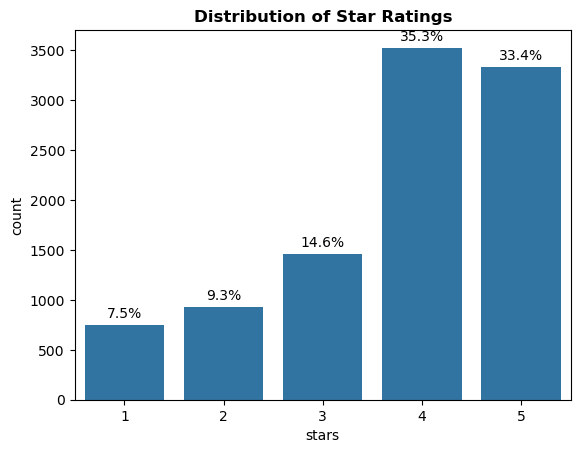

In [7]:
ax = sns.countplot(data=df, x='stars')

labels = [f'{p.get_height() / len(df) * 100:.1f}%' for p in ax.patches]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.title('Distribution of Star Ratings', fontweight='bold')
plt.show()

- Positive reviews (4–5 stars): Account for over 68% of all records -> users tend to leave favorable ratings.
- Negative reviews (1–2 stars): Make up only 17% of the reviews.

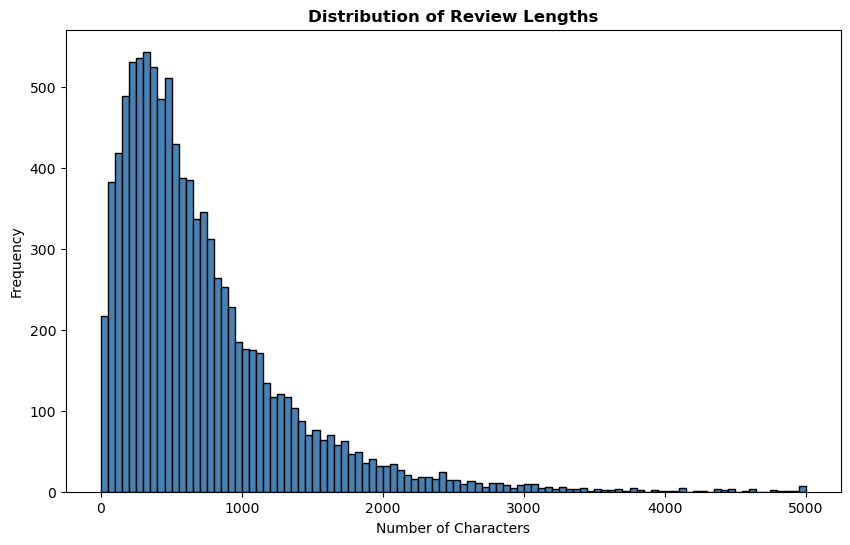

In [8]:
# Calculate the length of the text
df['length'] = df['text'].apply(len)

# histogram
df['length'].plot(bins=100, kind='hist', figsize=(10, 6), color='steelblue', edgecolor='black')

plt.title('Distribution of Review Lengths', fontweight='bold')
plt.xlabel('Number of Characters')

plt.show()

- The majority of reviews are short,
- but there is a long "tail" (up to 5,000 characters).

In [9]:
df.length.describe()

count    10000.000000
mean       710.738700
std        617.399827
min          1.000000
25%        294.000000
50%        541.500000
75%        930.000000
max       4997.000000
Name: length, dtype: float64

In [10]:
# Inspect the text of the longest review
df[df['length'] == 4997]['text'].iloc[0]

'In our continuing quest to identify cool, locally owned places to eat and/or drink, Caroline and I auditioned Vintage 95 last night. \n\nBefore I go further, understand that whenever I go out for eats or drinks, I have  in  mind a Platonic Ideal of the Bar/Pub/Eatery I most want to frequent. I\'m on a constant quest to find that  Ideal expressed in Real Life. \n\nVintage 95 isn\'t quite there, but it\'s damn close. If I ever give something Five Stars, you\'ll know it has pegged my Platonic Ideal. Anyway...\n\nThe plan last night was for drinks. No plans for food, just Adult Beverages and warm conversation. But it turned into more.\n\nThe location in downtown Chandler is terrific for us. The owners have created a very fine visual experience - leather, stone, dark woods, good lighting. And they don\'t have the music turned up so loud that you CANNOT HAVE A CONVERSATION. This is one of my pet peeves. If I want to stare at people move their mouths while enduring an aural assault, I\'ll st

In [11]:
# Inspect the text of the shortest review
df[df['length'] == 1]['text'].iloc[0]

'X'

In [12]:
# Inspect the text of a mid-range/average length review
df[df['length'] == 541]['text'].iloc[0]

"I love this place.  The first time I went, I had my mom and my sister with me.  We all got pedicures and by far the best foot massages I've had at any of these nail places.  The thing that really impresses me the most is that after only one visit... the next time I came in- they greeted me by my name. How often does that happen?  Hello, customer service- welcome back.  It's husband and wife owned and operated and they are as nice as can be. Love it here.  Great atmosphere, friendly, good service, affordable.  You won't be disappointed."

In [13]:
# Calculate the average review length for each star rating
df.groupby('stars')['length'].mean()

stars
1    826.515354
2    842.256742
3    758.498289
4    712.923142
5    624.999101
Name: length, dtype: float64

On average, negative reviews (1-2 stars) are longer (826–842 characters) compared to positive reviews (5 stars, 624 characters).

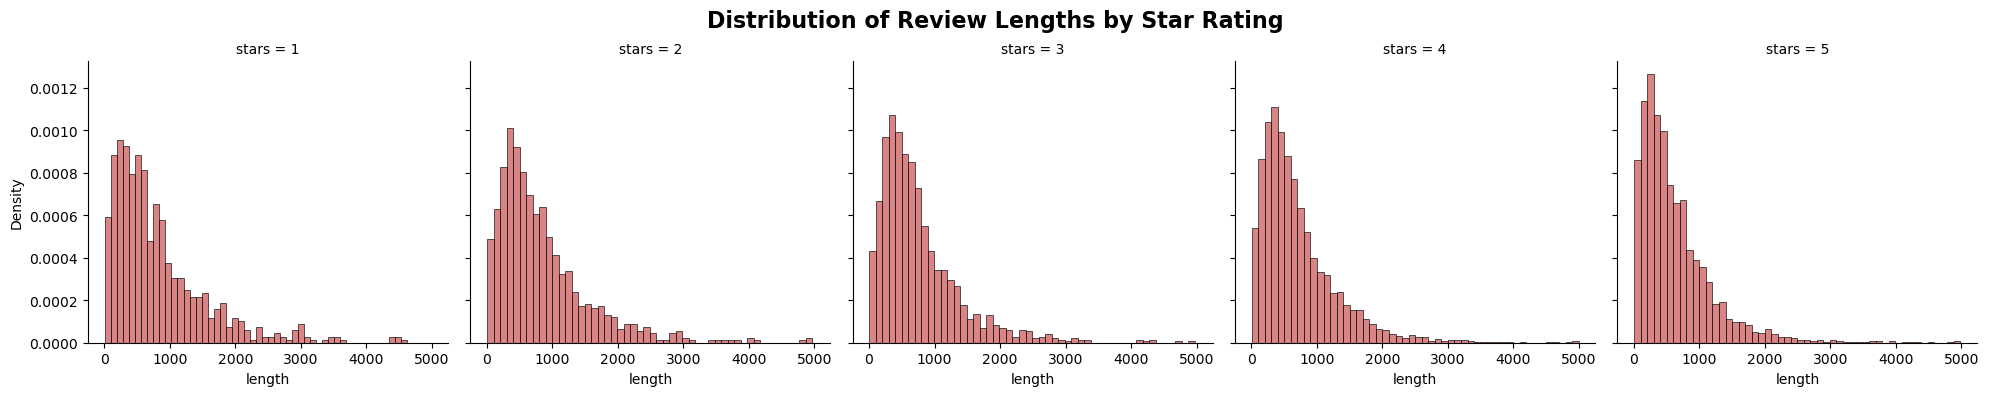

In [14]:
g = sns.FacetGrid(df, col='stars', col_wrap=5, height=4)
g.map_dataframe(sns.histplot, x='length', bins=50, color='indianred', stat='density')
g.fig.suptitle('Distribution of Review Lengths by Star Rating', fontsize=16, fontweight='bold')
g.fig.subplots_adjust(top=0.85)

plt.show()

The shape of the distribution is similar across all groups:  
- A peak around 400–600 characters.  
- A sharp drop-off after 1,000.  
- A long right tail extending up to 5,000.

In [15]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek
df['day'] = df['date'].dt.day
df['is_weekend'] = df['dayofweek'] >=5

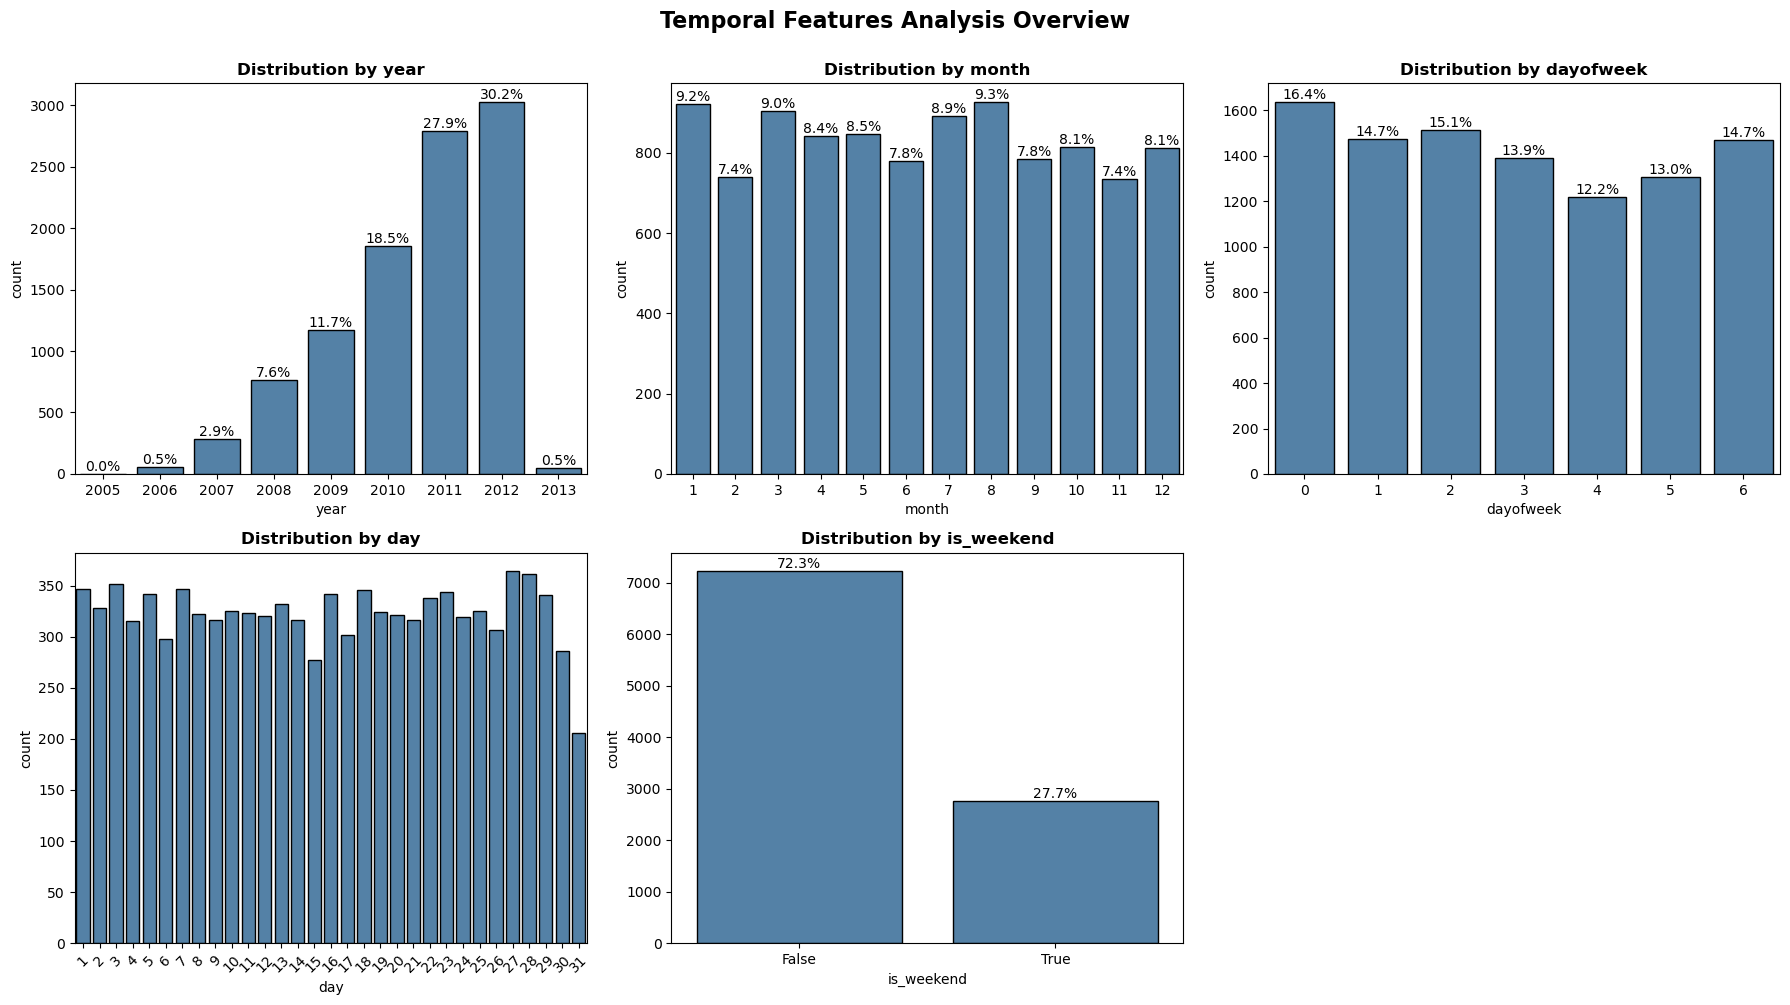

In [16]:
date_features = ['year', 'month', 'dayofweek', 'day', 'is_weekend']

fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()  

for i, feature in enumerate(date_features):
    sns.countplot(data=df, x=feature, color='steelblue', edgecolor='black', ax=ax[i])
    
    if feature != 'day':
        labels = [f'{p.get_height() / len(df) * 100:.1f}%' for p in ax[i].patches]
        ax[i].bar_label(ax[i].containers[0], labels=labels, fontsize=10)
    ax[i].set_title(f'Distribution by {feature}', fontweight='bold')
    ax[i].set_xlabel(feature)
    
    if feature == 'day':
        ax[i].tick_params(axis='x', rotation=45)

ax[5].set_visible(False)
fig.suptitle('Temporal Features Analysis Overview', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

- `year`: Activity peaks in 2011–2012, and the sharp drop afterwards is likely related to the data collection timeframe.
- `month`: Activity is completely uniform throughout the year with no visible seasonality.
- Day of the Week (`dayofweek`): Publication peaks early in the week, likely a delayed reaction to weekend visits.
- Day of the Month (`day`): Flat distribution with no patterns (the dip on the 31st is merely a calendar logic).

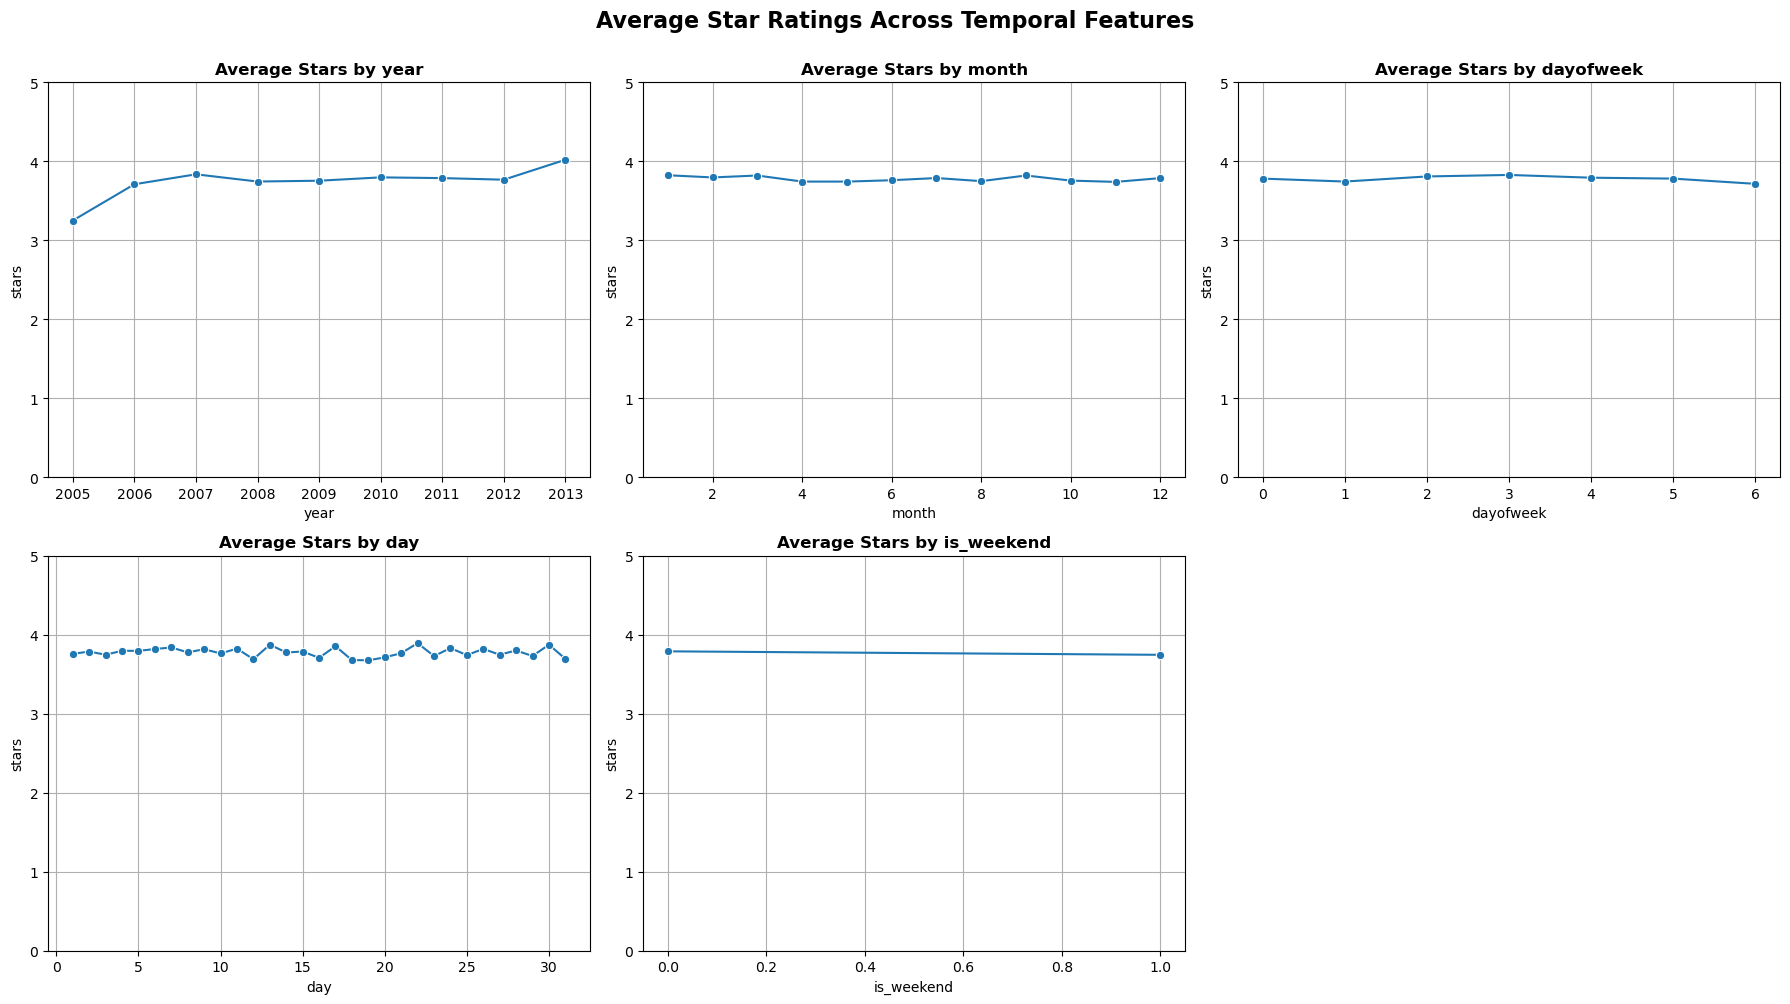

In [17]:
fig, ax = plt.subplots(2, 3, figsize=(18, 10))
ax = ax.flatten()

for i, feature in enumerate(date_features):
    date_stars_avr = df.groupby(feature)['stars'].mean().reset_index()
    sns.lineplot(data=date_stars_avr, x=feature, y='stars', marker='o', ax=ax[i])
    
    ax[i].set_ylim(0, 5)
    ax[i].grid(True)
    ax[i].set_title(f'Average Stars by {feature}', fontsize=12, fontweight='bold')

ax[5].set_visible(False)

fig.suptitle('Average Star Ratings Across Temporal Features', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

- The trend lines are flat across all five plots.
- The average rating remains strictly within a narrow range (around 3.7–3.8 stars), regardless of the year, month, day of the week, or whether it is a weekend.
- This suggests that the time of publication likely has no impact on the overall sentiment of the review.

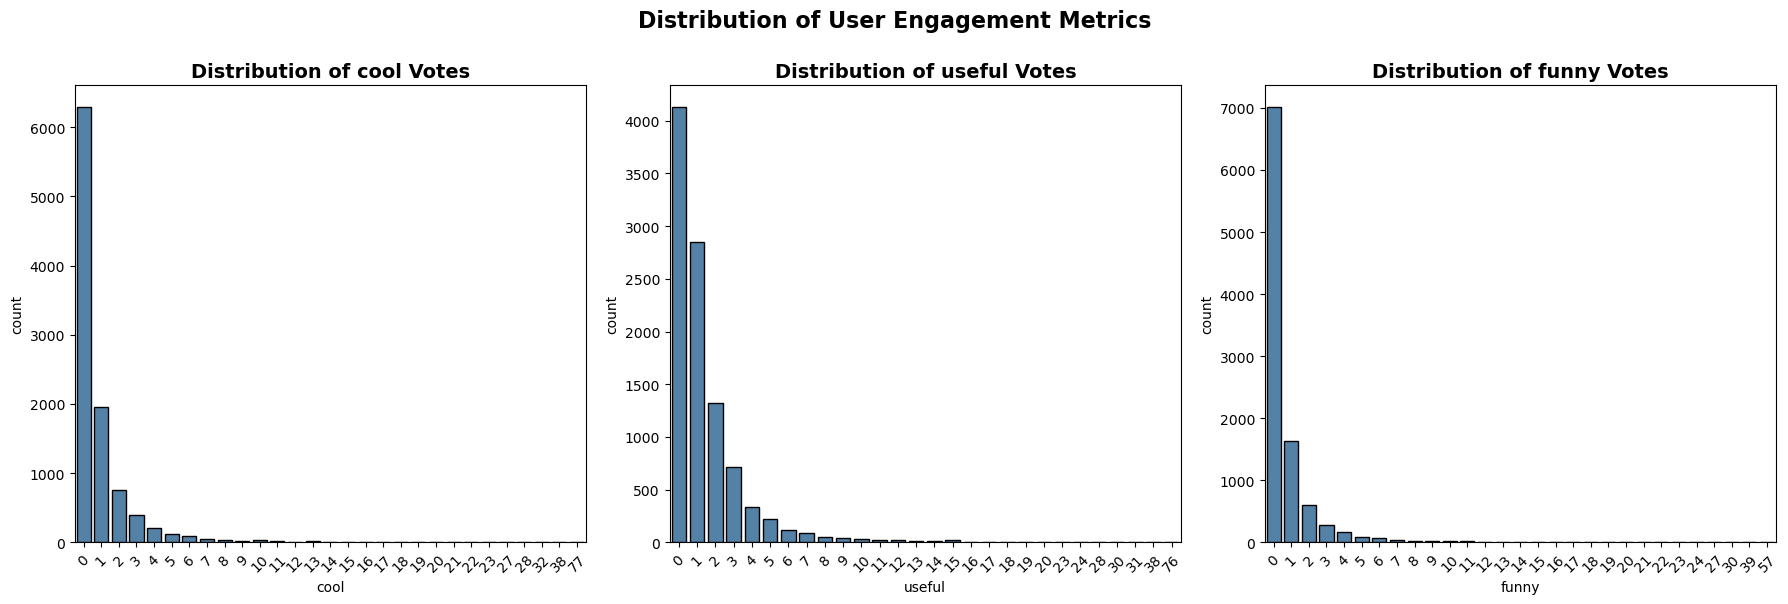

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(['cool', 'useful', 'funny']):
    sns.countplot(data=df, x=feature, color='steelblue', edgecolor='black', ax=ax[i])
    
    title_name = feature.title()
    ax[i].set_title(f'Distribution of {feature} Votes', fontsize=14, fontweight='bold')
    ax[i].tick_params(axis='x', rotation=45)

fig.suptitle('Distribution of User Engagement Metrics', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

- Almost all reviews fall within the 0–2 range, with only a small fraction scoring higher.
- However, extreme values (outliers) reaching 50+ are also present.
- Such long tails may be a sign of anomalous behavior (either viral reviews or artificial boosting).

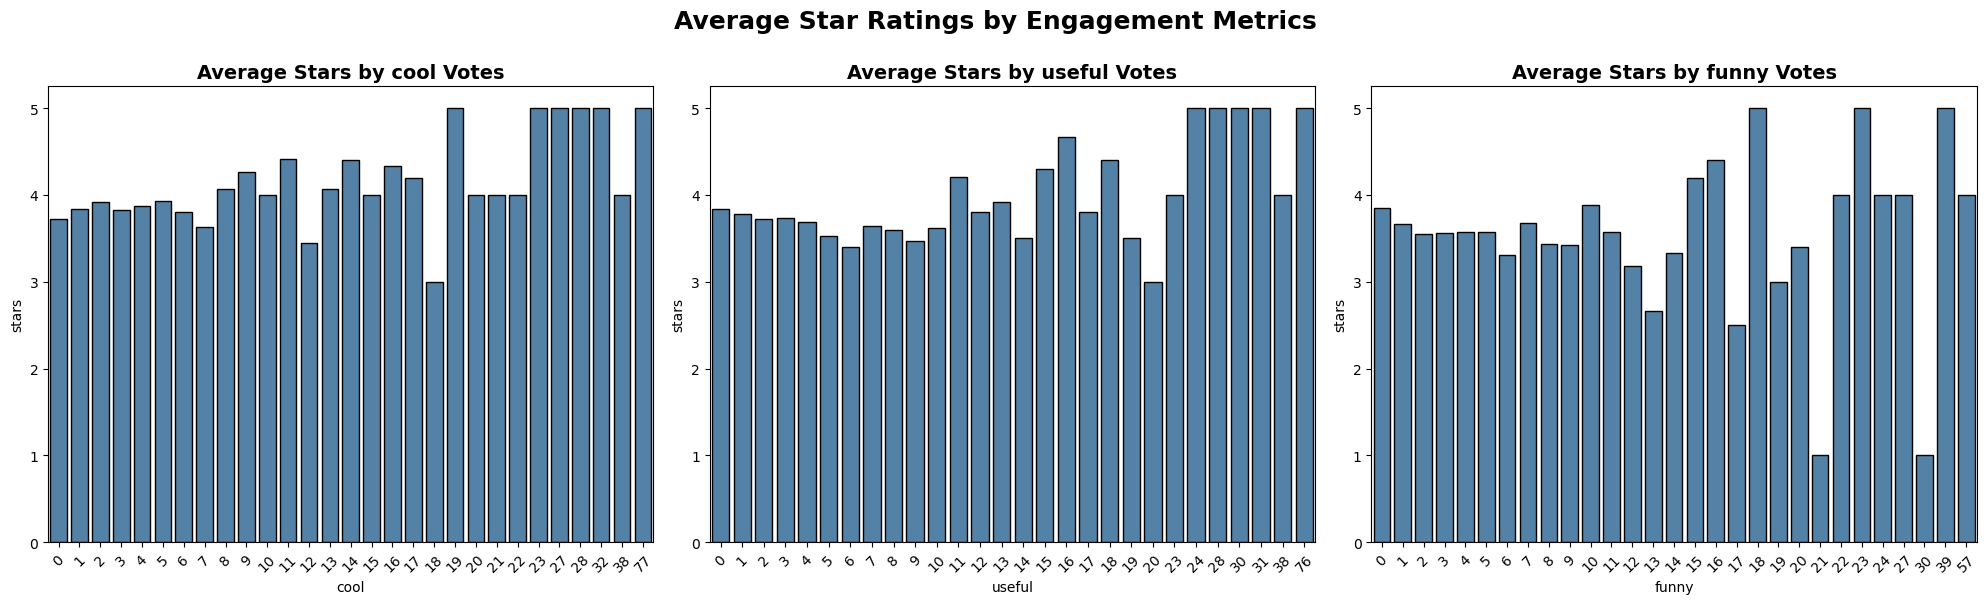

In [19]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

for i, feature in enumerate(['cool', 'useful', 'funny']):
    grouped_data = df.groupby(feature)['stars'].mean().reset_index()
    
    sns.barplot(data=grouped_data, x=feature, y='stars', ax=ax[i], color='steelblue', edgecolor='black')
    ax[i].set_title(f'Average Stars by {feature} Votes', fontsize=14, fontweight='bold')
    ax[i].tick_params(axis='x', rotation=45)

fig.suptitle('Average Star Ratings by Engagement Metrics', fontsize=18, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

**The charts display the average star rating of reviews based on the number of likes they received.**

**Across all three charts:**
- The average rating fluctuates around 3.5–5 stars, regardless of the number of likes.
- A high number of likes does not guarantee a high star rating.

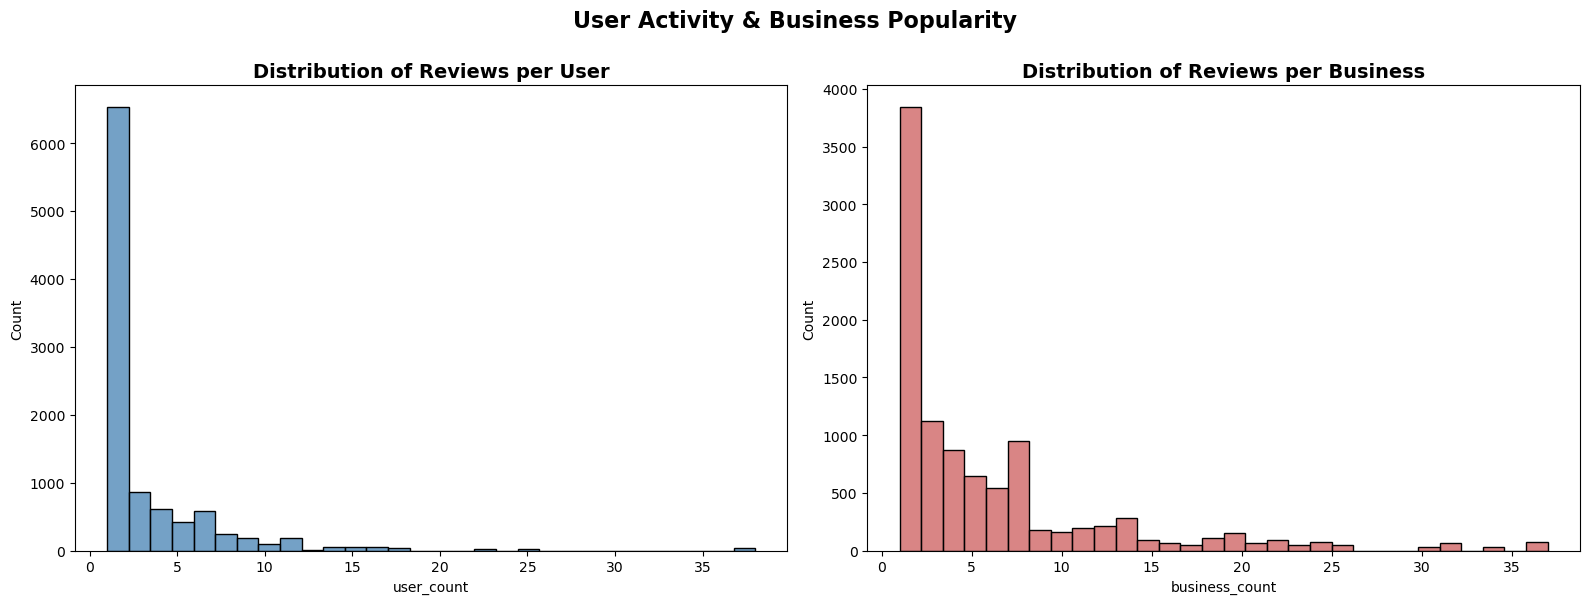

In [20]:
# Number of reviews per user
df['user_count'] = df['user_id'].map(df['user_id'].value_counts())

# Number of reviews per business
df['business_count'] = df['business_id'].map(df['business_id'].value_counts())

# VISUALIZATION
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# User asctivity
sns.histplot(data=df, x='user_count', bins=30, color='steelblue', edgecolor='black', ax=ax[0])
ax[0].set_title('Distribution of Reviews per User', fontsize=14, fontweight='bold')

# Business popularity
sns.histplot(data=df, x='business_count', bins=30, color='indianred', edgecolor='black', ax=ax[1])
ax[1].set_title('Distribution of Reviews per Business', fontsize=14, fontweight='bold')

fig.suptitle('User Activity & Business Popularity', fontsize=16, fontweight='bold', y=1)

plt.tight_layout()
plt.show()

**User Activity:**
- The vast majority of users have written only 1 review.
- Very few users write more than 5 reviews, and only a handful write more than 20.
- This can be crucial for detecting anomalous users (e.g., bots, fake accounts, or SMM managers mass-posting reviews).

**Business Popularity:**
- Almost all businesses have received only 1–2 reviews.
- A small number of businesses have received 10, 20, or 30+ reviews.

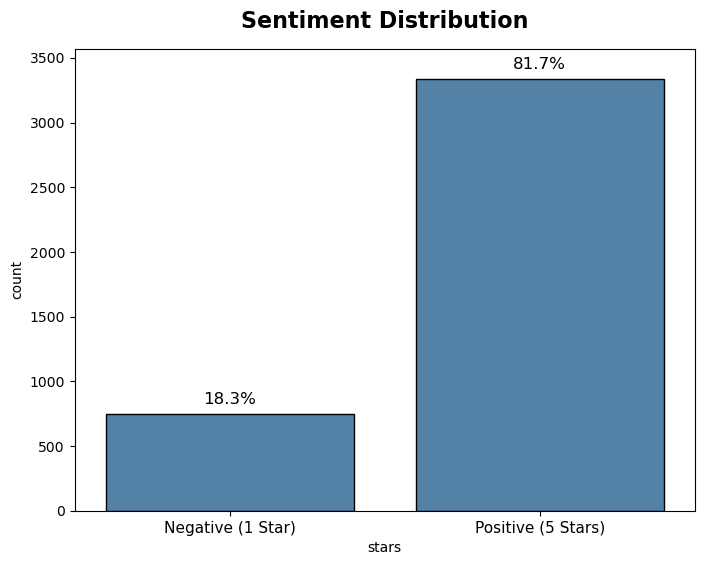

In [21]:
# Prepare the target variable for binary classification
df = df[df['stars'].isin([1, 5])].copy()

# Replace ratings with binary classes
df['stars'] = df['stars'].replace({1: 0, 5: 1})

# Plotting the chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='stars', color='steelblue', edgecolor='black')

# Calculate and add percentages
labels = [f'{p.get_height() / len(df) * 100:.1f}%' for p in ax.patches]
ax.bar_label(ax.containers[0], labels=labels, padding=5, fontsize=12)

ax.set_ylim(0, df['stars'].value_counts().max() * 1.07)
ax.set_title('Sentiment Distribution', fontsize=16, fontweight='bold', pad=15)
ax.set_xticklabels(['Negative (1 Star)', 'Positive (5 Stars)'], fontsize=11)

plt.show()

**Class Imbalance:** The data is heavily skewed towards positive sentiment.

In [22]:
# Number of words in the review 
df['word_count'] = df['text'].apply(count_words_spacy)

# Number of sentences in the review
df['num_sentences'] = df['text'].apply(count_sentences_spacy)

# Number of numeric tokens (digits and spelled-out numbers) in the review
df['digit_count'] = df['text'].apply(count_numbers_spacy)

# Number of exclamation marks (!) in the review
df['num_exclam'] = df['text'].str.count(r'!')

# Number of question marks (?) in the review
df['num_questions'] = df['text'].str.count(r'\?')

In [23]:
afinn = Afinn()
vader = SentimentIntensityAnalyzer()
bing_pos = set(opinion_lexicon.positive())
bing_neg = set(opinion_lexicon.negative())

afinn_scores = []
vader_scores = []
bing_scores = []
nrc_positive = []
nrc_negative = []

# Calculate sentiment scores
for text in df['text']:
    
    # Tokenize text
    tokens = word_tokenize(text.lower())

    # AFINN score (sum of predefined word polarities)
    afinn_scores.append(afinn.score(text))

    # VADER compound score (normalized between -1 and 1)
    vader_scores.append(vader.polarity_scores(text)['compound'])

    # Bing score (+1 for positive words, -1 for negative words)
    bing_score = sum(1 if word in bing_pos else -1 if word in bing_neg else 0 for word in tokens)
    bing_scores.append(bing_score)

     # NRC emotion scores (counting occurrences of positive/negative associations)
    emotions = NRCLex(text).raw_emotion_scores
    nrc_positive.append(emotions.get('positive', 0))
    nrc_negative.append(emotions.get('negative', 0))

# Assign scores to DataFrame
df['score_afinn'] = afinn_scores
df['score_vader'] = vader_scores
df['score_bing'] = bing_scores
df['nrc_pos'] = nrc_positive
df['nrc_neg'] = nrc_negative

# Normalize dictionary scores by the length of the review
df['score_afinn_norm'] = df['score_afinn'] / df['word_count']
df['score_bing_norm'] = df['score_bing'] / df['word_count']
df['nrc_pos_norm'] = df['nrc_pos'] / df['word_count']
df['nrc_neg_norm'] = df['nrc_neg'] / df['word_count']

# Calculate the average sentiment score (VADER) per business
average_vader = df.groupby('business_id')['score_vader'].transform('mean')

# Calculate the absolute deviation
df['vader_deviation'] = abs(df['score_vader'] - average_vader)

# Extract basic sentiment metrics using TextBlob.
df[['polarity', 'subjectivity']] = df['text'].apply(get_textblob_metrics)

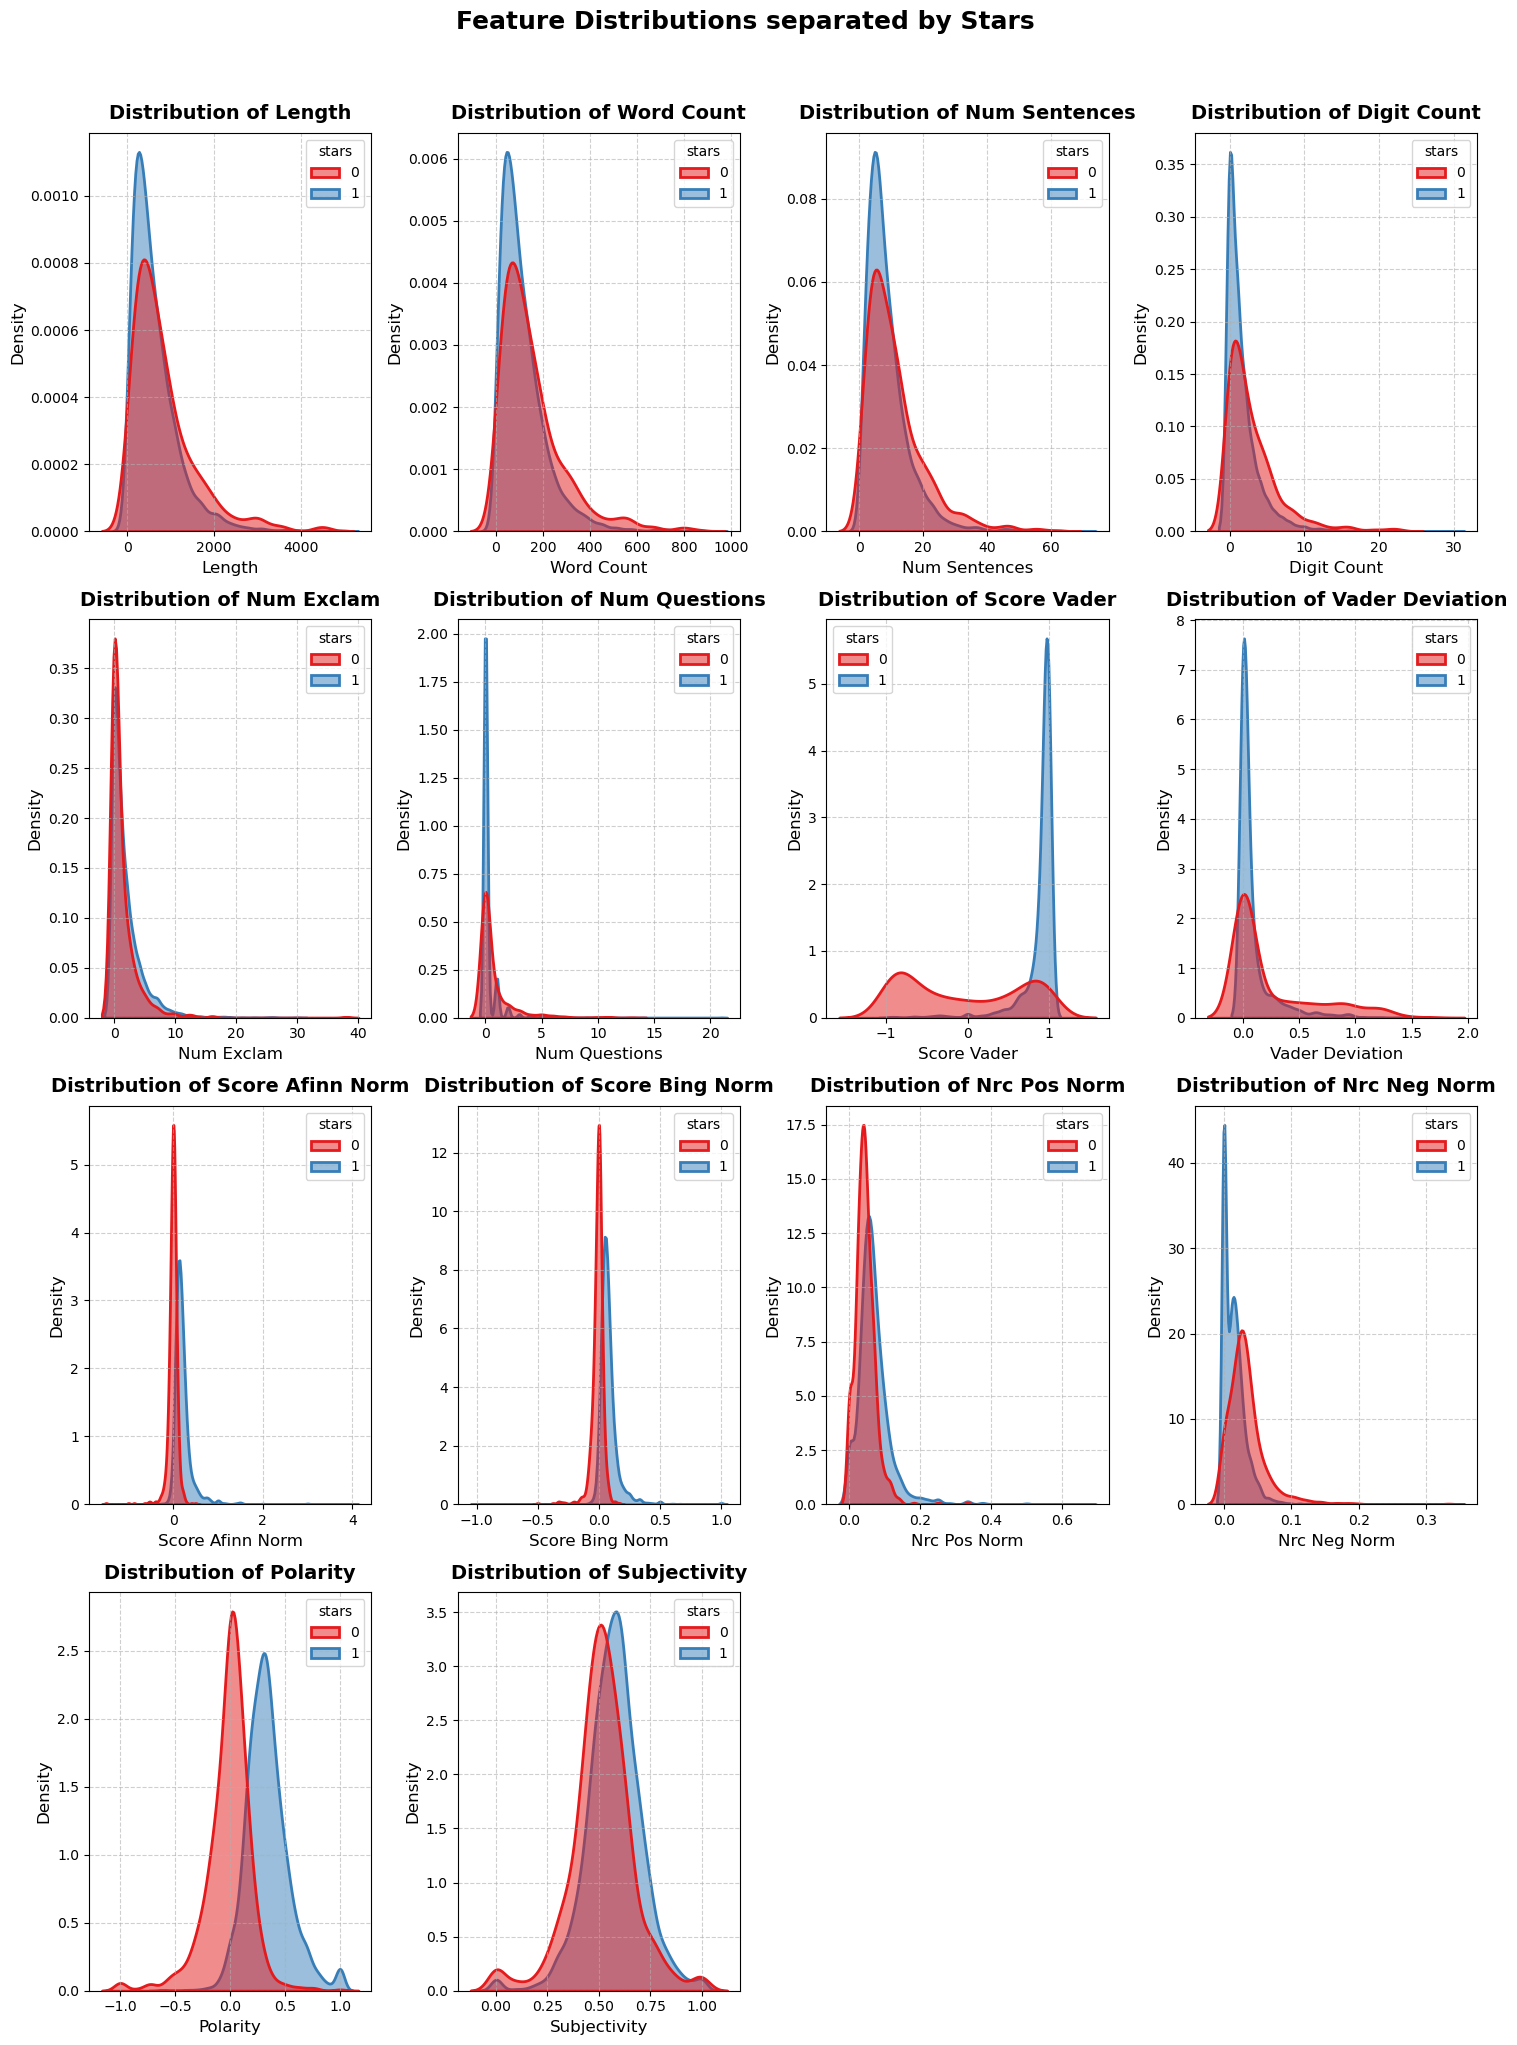

In [24]:
features_to_plot = [
    'length',
    'word_count',
    'num_sentences',
    'digit_count',
    'num_exclam', 
    'num_questions',
    'score_vader',
    'vader_deviation',
    'score_afinn_norm', 
    'score_bing_norm', 
    'nrc_pos_norm',
    'nrc_neg_norm',
    'polarity',
    'subjectivity'
]

plot_kde_grid(
    df=df,                      
    feature_cols=features_to_plot,
    target_col='stars',         
    cols=4                    
)

- `score_vader`, `score_afinn_norm`, `score_bing_norm`, `nrc_neg_norm`, and `polarity`. A distinct separation between the target class distributions is observed.
- `word_count`, `num_sentences`, `length`, `digit_count`, and `subjectivity`. Although the plots partially overlap, the shape of the distributions differs. Negative reviews tend to be longer than positive ones.
- `num_exclam`, `num_questions`, and `nrc_pos_norm`. The class distributions almost completely overlap each other.

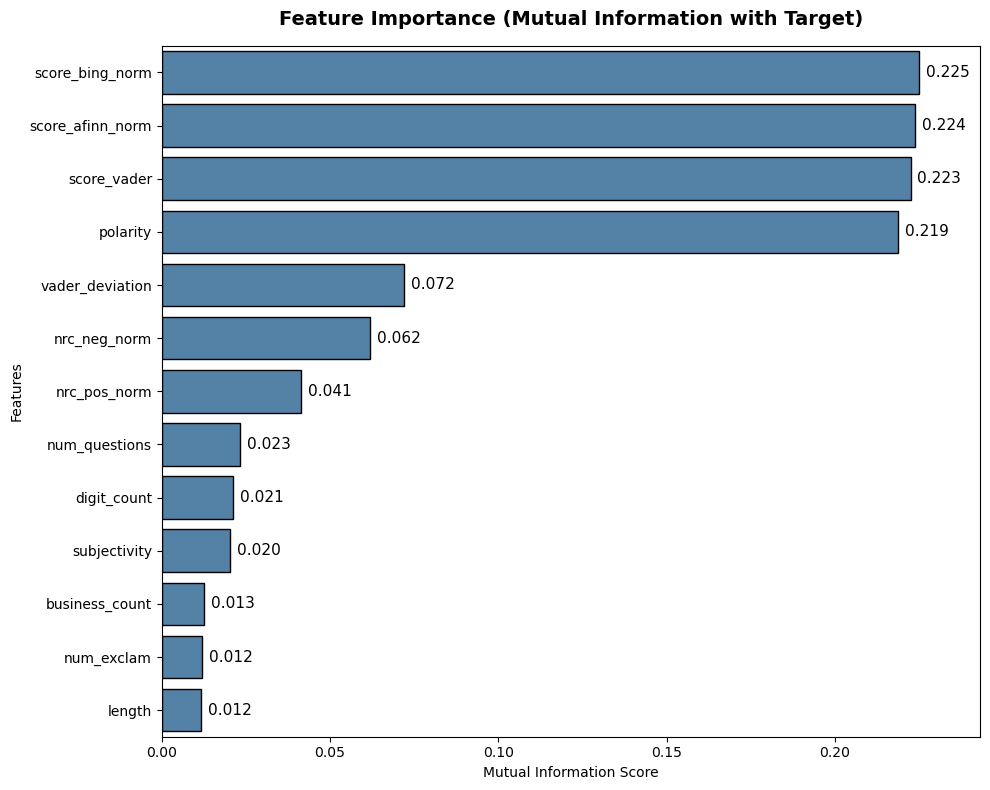

In [25]:
features_to_keep = [
    'cool', 'useful', 'funny', 'length', 'year', 'month', 'dayofweek',
    'day', 'is_weekend', 'user_count', 'business_count', 'word_count',
    'num_sentences', 'digit_count', 'num_exclam', 'num_questions',
    'score_vader', 'score_afinn_norm', 'score_bing_norm', 
    'nrc_pos_norm', 'nrc_neg_norm', 'vader_deviation', 'polarity', 'subjectivity'
]

X = df[features_to_keep].copy()
y = df['stars']

# Identify discrete features (if the number of unique values is < 15)
discrete_flags = [X[feature].nunique() < 15 for feature in features_to_keep]

# Calculate mutual information
mi = mutual_info_classif(X, y, discrete_features=discrete_flags, random_state=0)

# Convert the result to a Series, keep only significant features (MI > 0.01), and sort
mi_series = pd.Series(mi, index=features_to_keep)
mi_filtered = mi_series[mi_series > 0.01].sort_values(ascending=False)

# Visualization 
plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=mi_filtered.values, 
    y=mi_filtered.index, 
    color='steelblue', 
    edgecolor='black'
)

ax.bar_label(ax.containers[0], fmt='%.3f', padding=5, fontsize=11)

# Increase the X-axis limit by 8% to prevent labels from being cut off
ax.set_xlim(0, mi_filtered.max() * 1.08)

plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Feature Importance (Mutual Information with Target)", fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

- **(MI > 0.21)**: `score_bing_norm`, `polarity`, `score_afinn_norm`, and `score_vader`. Direct semantic sentiment scores contain the primary signal regarding the target variable.
- **(MI 0.04 - 0.06)**: NRC lexicon metrics (`nrc_neg_norm`, `nrc_pos_norm`) demonstrate moderate information value and serve as secondary factors.
- **(MI < 0.02)**: Structural text characteristics (`num_questions`, `subjectivity`, `length`, `num_sentences`, etc.) show a minimal non-linear relationship with the target.

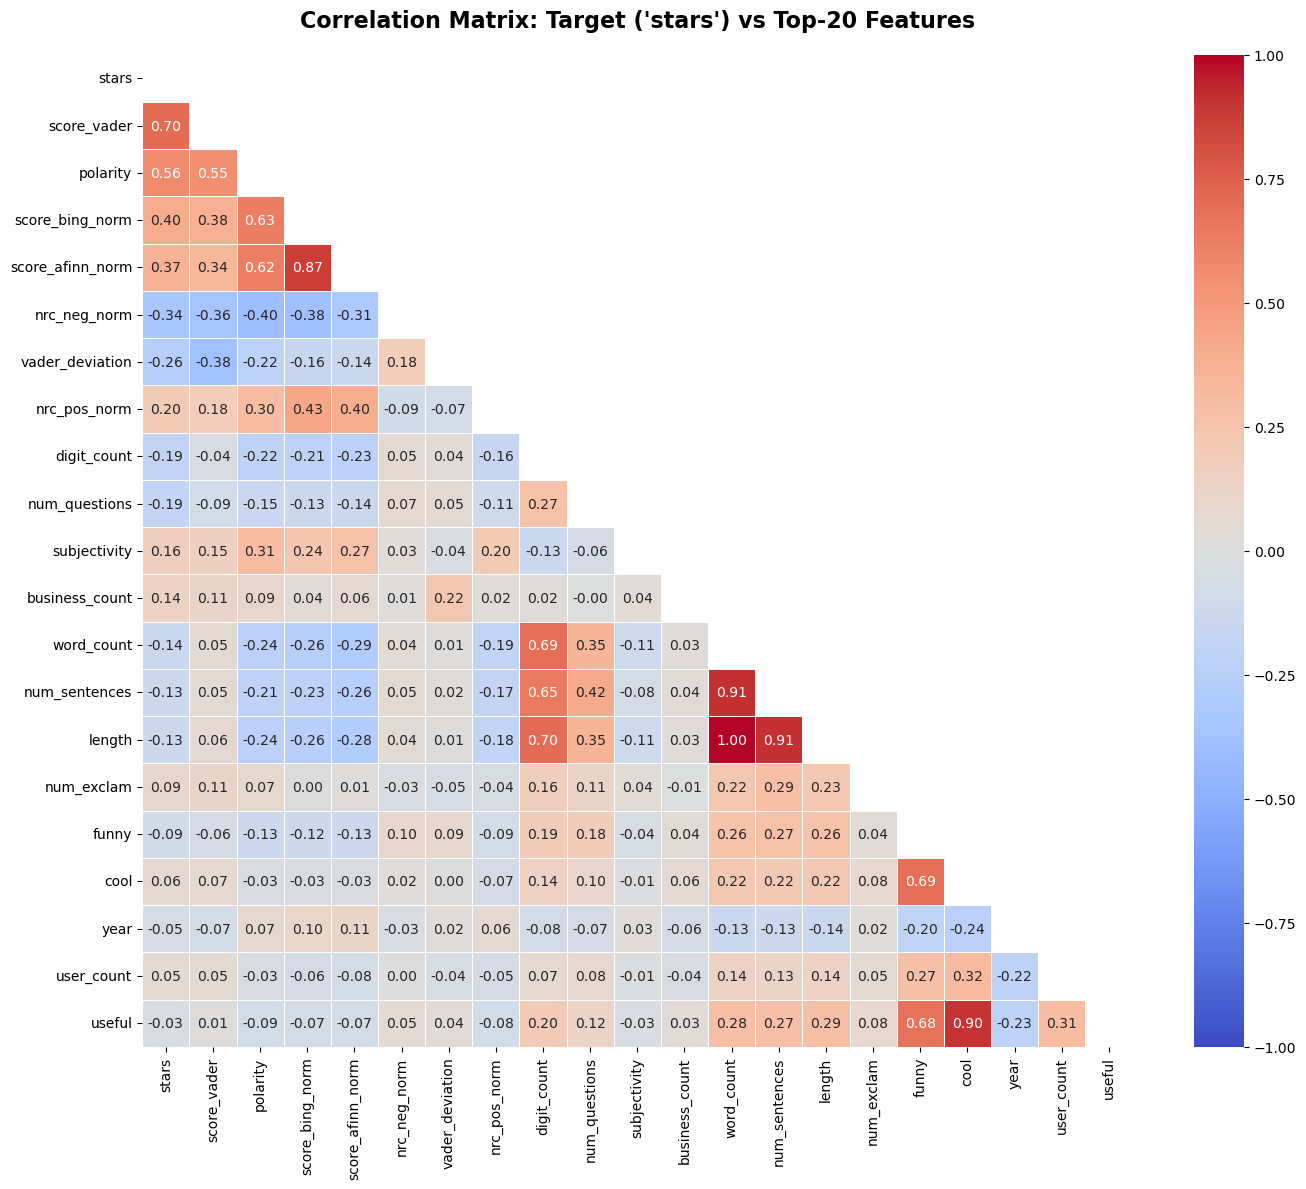

In [26]:
df_corr = df.drop(columns=['score_afinn', 'score_bing', 'nrc_pos', 'nrc_neg'])

# Select the top 20 features by correlation with the target variable
cor_target = df_corr.corr(numeric_only=True)['stars'].drop('stars')
top20_features = cor_target.abs().sort_values(ascending=False).head(20).index.tolist()

# Add 'stars' to the first position
top_features = ['stars'] + top20_features

# Calculate the correlation matrix
corr_matrix = df_corr[top_features].corr()

# np.ones_like creates a matrix of ones, np.triu keeps only the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Visualization
plt.figure(figsize=(14, 12))

sns.heatmap(
    corr_matrix, 
    mask=mask,                 # Apply the mask (hide the duplicating upper triangle)
    annot=True,            
    fmt=".2f",                 # Round to two decimal places
    cmap="coolwarm",          
    vmin=-1, vmax=1, center=0, # Fix the scale from -1 to 1 so that 0 is strictly in the center
    linewidths=0.5,            
)

plt.title("Correlation Matrix: Target ('stars') vs Top-20 Features", fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

- The strongest linear relationship with the target variable (`stars`) is demonstrated by the semantic metrics: `score_vader`, `polarity`, and `score_afinn_norm`.
- The most pronounced factor with an inverse relationship (negative correlation) is the negative emotion level — `nrc_neg_norm`.
- Predictor multicollinearity is observed in the cluster of structural features ($0.90–1.00$) related to text volume (`length`, `word_count`, `num_sentences`).

In [27]:
df.to_parquet('../data/yelp_data_prepared.parquet')